<a href="https://colab.research.google.com/github/Julianmoralez/Retos-Colab/blob/Retos-Colab/Parcial_1_Analitica_De_negocios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Reto Parcial I — Analítica de Negocios

## 0. Instalación e Importación de Librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Librerías estándar de análisis ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Machine Learning ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# ── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

import warnings
warnings.filterwarnings('ignore')
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 1. Carga y Análisis Exploratorio de Datos (EDA)

In [ ]:
# ── Carga del dataset ──────────────────────────────────────────────────────
# Opción A: Si el archivo está en el entorno Colab (subir manualmente con files.upload())
# from google.colab import files
# uploaded = files.upload()  # seleccionar diabetes.csv

# Opción B: Leer directamente (si el CSV usa punto y coma como separador)
# El dataset original de Kaggle usa coma; si el tuyo usa punto y coma, cambia sep
df = pd.read_csv('/content/diabetes.csv', sep=';')   # ← ajustar sep=',' si es necesario

print(f'📊 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(10)

📊 Dimensiones del dataset: 768 filas × 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1
5,5,116,74,0,0,25.6000,0.2010,30,0
6,3,78,50,32,88,31.0000,0.2480,26,1
7,10,115,0,0,0,35.3000,0.1340,29,0
8,2,197,70,45,543,30.5000,0.1580,53,1
9,8,125,96,0,0,0.0000,0.2320,54,1


In [ ]:
# ── Información general ────────────────────────────────────────────────────
print('=' * 55)
print('INFORMACIÓN GENERAL DEL DATASET')
print('=' * 55)
df.info()
print()
print('Tipos de datos por variable:')
print(df.dtypes)

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Tipos de datos por variable:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int6

In [ ]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────
print('ESTADÍSTICAS DESCRIPTIVAS')
df.describe().T

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,120.8945,31.9726,0.0000,99.0000,117.0000,140.2500,199.0000
BloodPressure,768.0000,69.1055,19.3558,0.0000,62.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,20.5365,15.9522,0.0000,0.0000,23.0000,32.0000,99.0000
Insulin,768.0000,79.7995,115.2440,0.0000,0.0000,30.5000,127.2500,846.0000
BMI,768.0000,31.9926,7.8842,0.0000,27.3000,32.0000,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000



 DISTRIBUCIÓN DE PACIENTES:
      Categoría  Cantidad  Porcentaje (%)
No Diabetes (0)       500         65.1042
   Diabetes (1)       268         34.8958


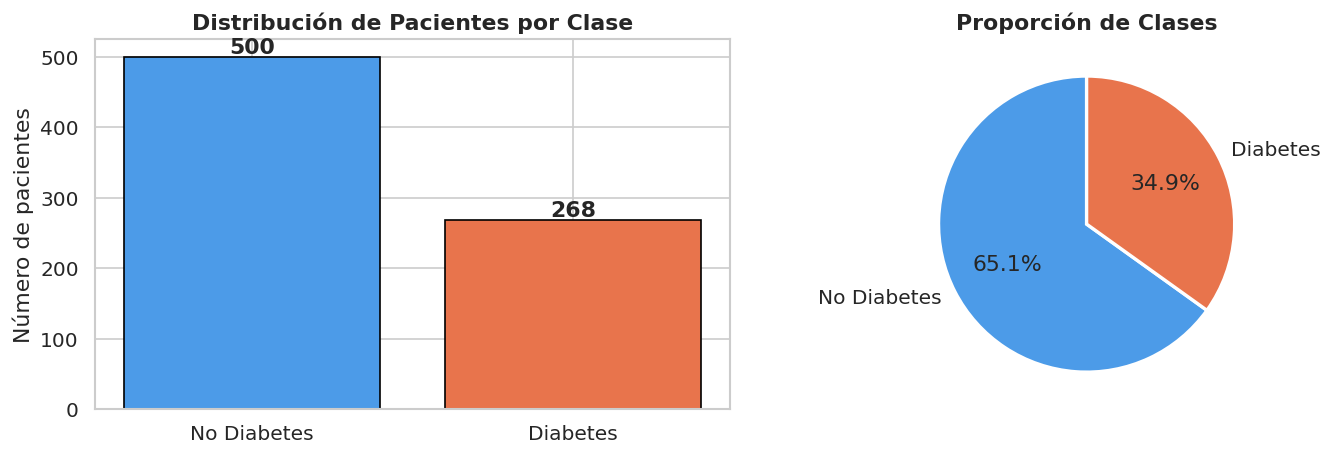

⚠️  Desbalance de clases detectado: 65.1% No Diabetes vs 34.9% Diabetes


In [ ]:
# ── Distribución de la variable objetivo ──────────────────────────────────
conteo = df['Outcome'].value_counts()
porcentaje = df['Outcome'].value_counts(normalize=True) * 100

resumen_outcome = pd.DataFrame({
    'Categoría': ['No Diabetes (0)', 'Diabetes (1)'],
    'Cantidad': [conteo[0], conteo[1]],
    'Porcentaje (%)': [porcentaje[0], porcentaje[1]]
})
print('\n DISTRIBUCIÓN DE PACIENTES:')
print(resumen_outcome.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colores = ['#4C9BE8', '#E8744C']
axes[0].bar(['No Diabetes', 'Diabetes'], [conteo[0], conteo[1]], color=colores, edgecolor='black')
axes[0].set_title('Distribución de Pacientes por Clase', fontweight='bold')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate([conteo[0], conteo[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie([conteo[0], conteo[1]], labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', bbox_inches='tight')
plt.show()
print('⚠️  Desbalance de clases detectado: 65.1% No Diabetes vs 34.9% Diabetes')

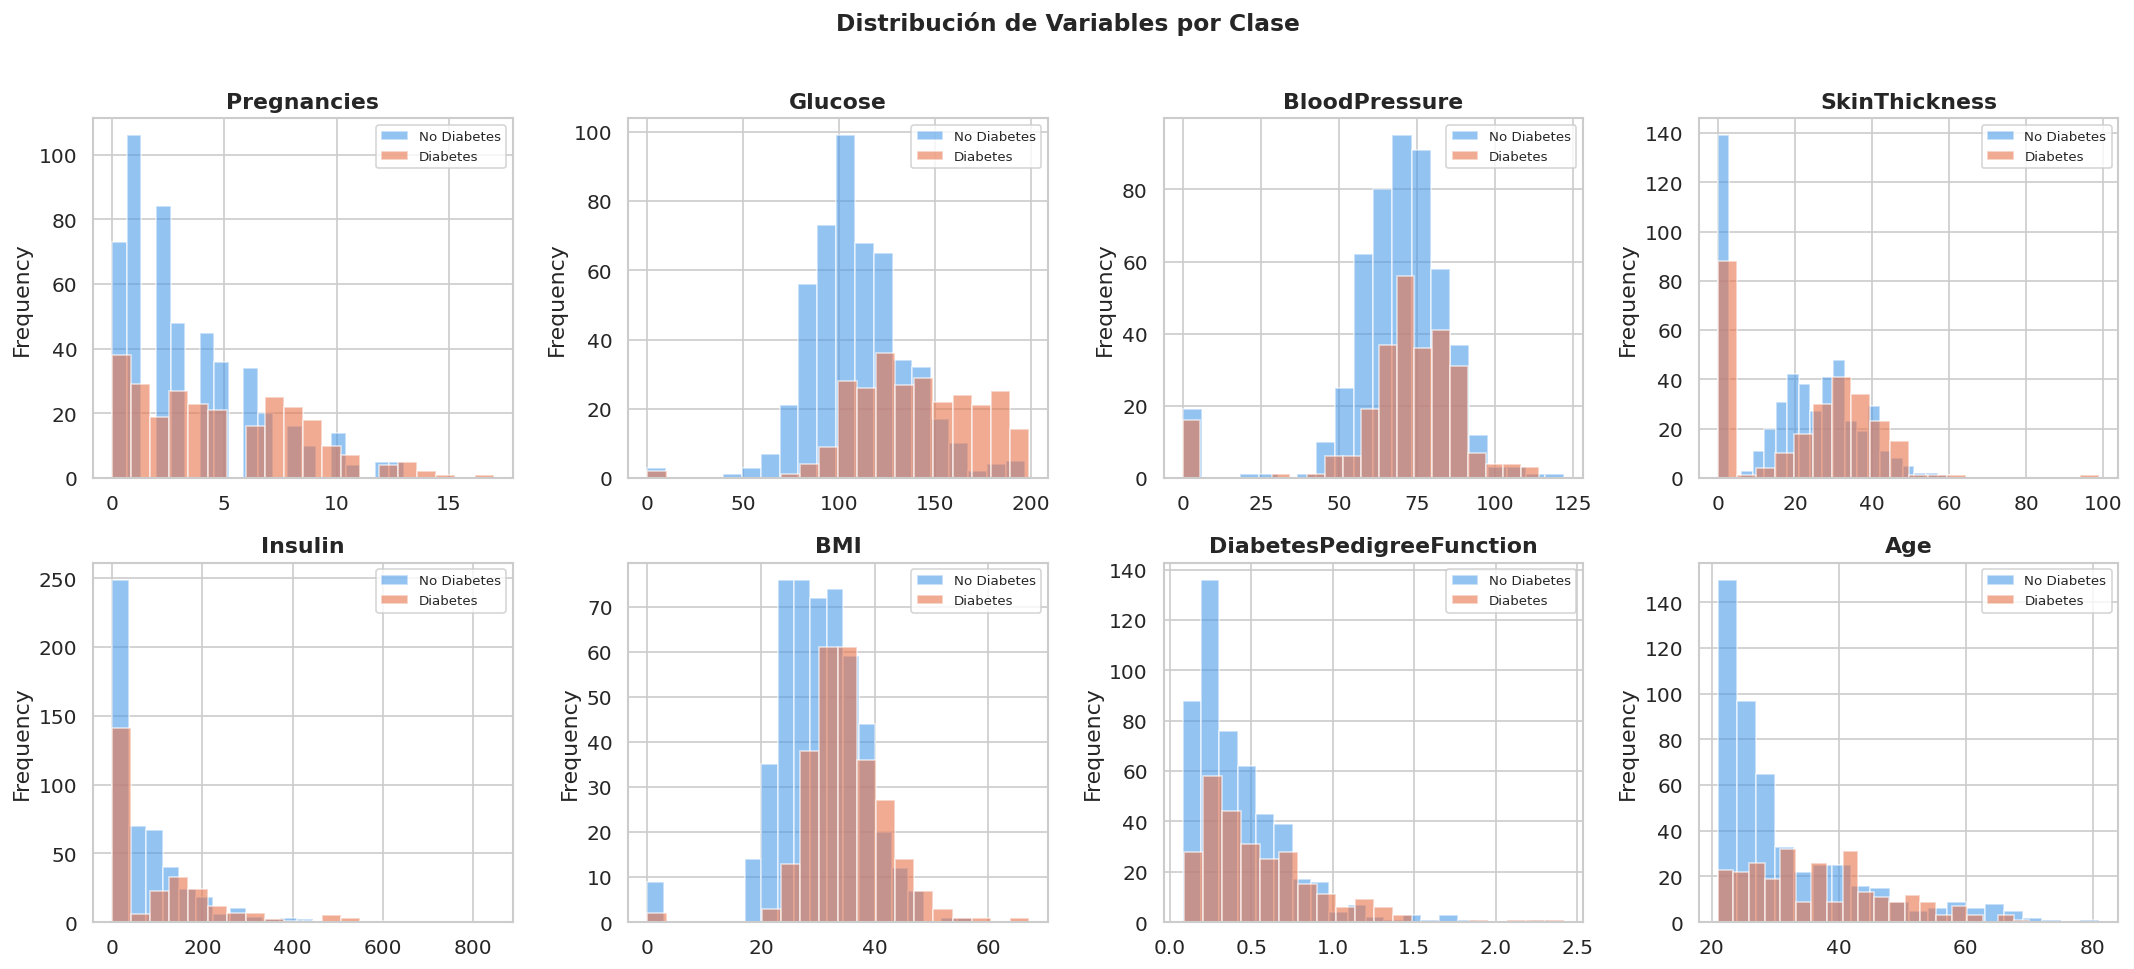

In [ ]:
# ── Distribuciones por variable y clase ───────────────────────────────────
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome'] == 0][col].plot(kind='hist', ax=axes[i], alpha=0.6,
                                      color='#4C9BE8', label='No Diabetes', bins=20)
    df[df['Outcome'] == 1][col].plot(kind='hist', ax=axes[i], alpha=0.6,
                                      color='#E8744C', label='Diabetes', bins=20)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de Variables por Clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuciones.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Estadísticas por categoría (responde al cuestionario) ─────────────────
print(' ESTADÍSTICAS POR CATEGORÍA DE CLASIFICACIÓN')
print('=' * 65)
grupo_stats = df.groupby('Outcome')[features].mean().T
grupo_stats.columns = ['No Diabetes (0)', 'Diabetes (1)']
grupo_stats['Diferencia'] = grupo_stats['Diabetes (1)'] - grupo_stats['No Diabetes (0)']
grupo_stats['Mayor en'] = grupo_stats['Diferencia'].apply(
    lambda x: '🔴 Diabetes' if x > 0 else '🔵 No Diabetes'
)
print(grupo_stats.to_string())
print()
print('➡️  La categoría Diabetes presenta valores promedio mayores en TODAS las variables.')

 ESTADÍSTICAS POR CATEGORÍA DE CLASIFICACIÓN
                          No Diabetes (0)  Diabetes (1)  Diferencia    Mayor en
Pregnancies                        3.2980        4.8657      1.5677  🔴 Diabetes
Glucose                          109.9800      141.2575     31.2775  🔴 Diabetes
BloodPressure                     68.1840       70.8246      2.6406  🔴 Diabetes
SkinThickness                     19.6640       22.1642      2.5002  🔴 Diabetes
Insulin                           68.7920      100.3358     31.5438  🔴 Diabetes
BMI                               30.3042       35.1425      4.8383  🔴 Diabetes
DiabetesPedigreeFunction           0.4297        0.5505      0.1208  🔴 Diabetes
Age                               31.1900       37.0672      5.8772  🔴 Diabetes

➡️  La categoría Diabetes presenta valores promedio mayores en TODAS las variables.


---
## 2. Análisis de Correlación

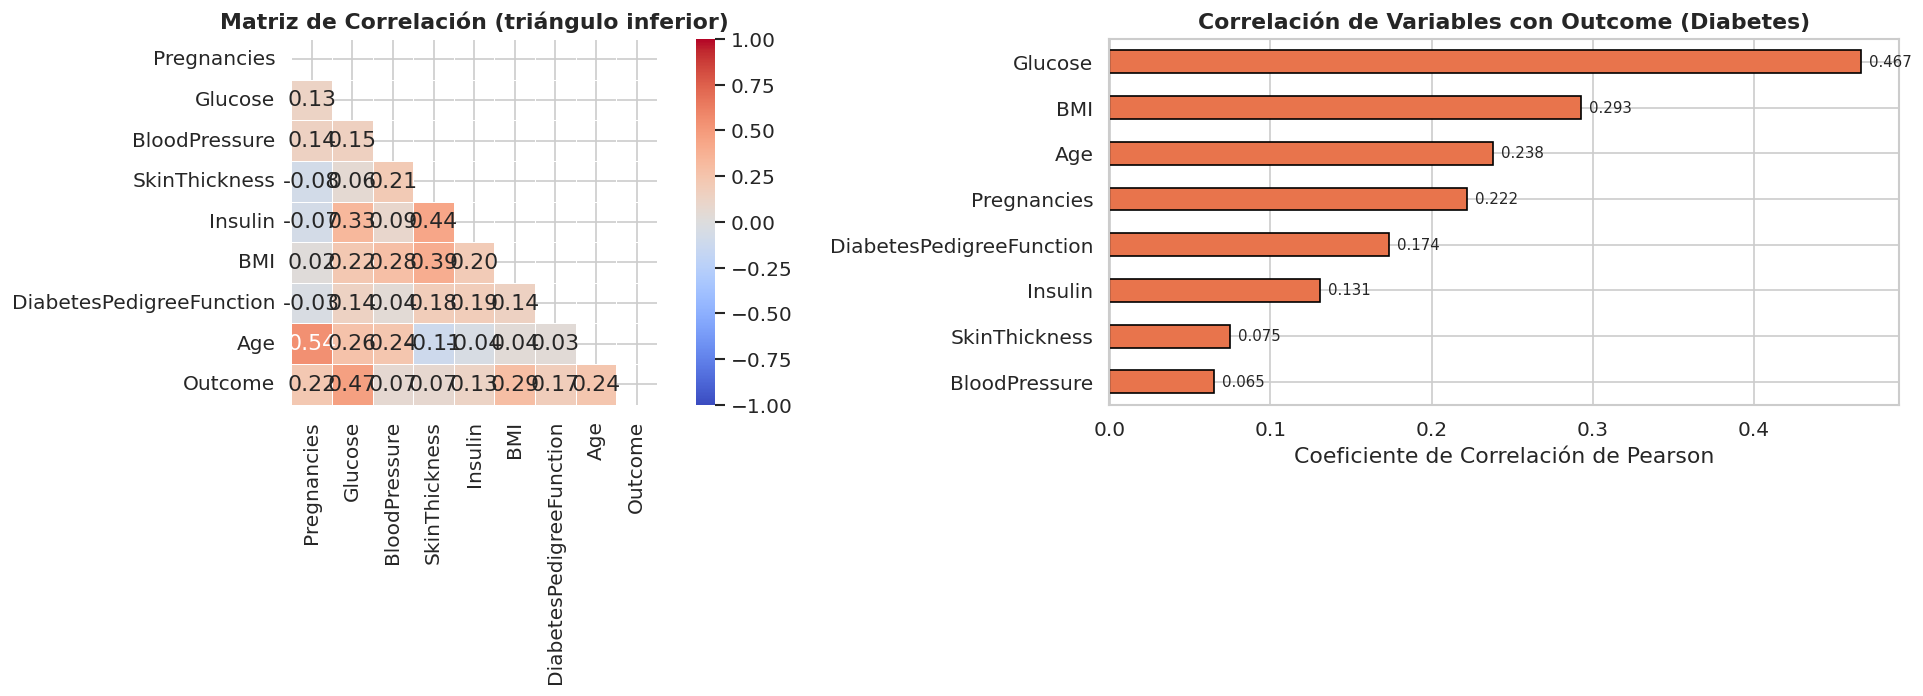


📌 CORRELACIÓN DE VARIABLES CON OUTCOME (ordenada):
Glucose                    0.4666
BMI                        0.2927
Age                        0.2384
Pregnancies                0.2219
DiabetesPedigreeFunction   0.1738
Insulin                    0.1305
SkinThickness              0.0748
BloodPressure              0.0651

🔗 Par de variables de entrada con mayor correlación entre sí: Pregnancies — Age
   Coeficiente: 0.5443

🏆 Variable de entrada con mayor correlación con Outcome: Glucose
   Coeficiente: 0.4666


In [ ]:
# ── Matriz de correlación ─────────────────────────────────────────────────
corr_matrix = df.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Matriz de Correlación (triángulo inferior)', fontweight='bold')

# Correlación con Outcome
corr_outcome = corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=True)
colores_bar = ['#E8744C' if v > 0 else '#4C9BE8' for v in corr_outcome]
corr_outcome.plot(kind='barh', ax=axes[1], color=colores_bar, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Variables con Outcome (Diabetes)', fontweight='bold')
axes[1].set_xlabel('Coeficiente de Correlación de Pearson')
for i, v in enumerate(corr_outcome):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005,
                 i, f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('correlacion.png', bbox_inches='tight')
plt.show()

print('\n📌 CORRELACIÓN DE VARIABLES CON OUTCOME (ordenada):')
print(corr_outcome.sort_values(ascending=False).to_string())
print()

# Par de variables más correlacionadas entre sí (excluyendo Outcome)
corr_features = corr_matrix.loc[features, features]
np.fill_diagonal(corr_features.values, 0)
max_pair_idx = np.unravel_index(np.abs(corr_features.values).argmax(), corr_features.shape)
v1, v2 = corr_features.index[max_pair_idx[0]], corr_features.columns[max_pair_idx[1]]
print(f'🔗 Par de variables de entrada con mayor correlación entre sí: {v1} — {v2}')
print(f'   Coeficiente: {corr_features.loc[v1, v2]:.4f}')
print(f'\n🏆 Variable de entrada con mayor correlación con Outcome: {corr_outcome.abs().idxmax()}')
print(f'   Coeficiente: {corr_outcome.abs().max():.4f}')

---
## 3. Preparación de Datos para Modelos Supervisados

In [ ]:
# ── Variables de entrada y salida ─────────────────────────────────────────
X = df[features].values
y = df['Outcome'].values

# ── Paciente a evaluar (XDp) ──────────────────────────────────────────────
XDp_raw = np.array([[2, 85, 65, 29, 94, 39.6, 0.93, 27]])
print(' Paciente a evaluar (XDp):')
print(pd.DataFrame(XDp_raw, columns=features).to_string(index=False))

# ── División train / test (80/20, stratified) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'\n Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

# ── Escalado (para K-Means y comparación) ────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
XDp_sc     = scaler.transform(XDp_raw)

 Paciente a evaluar (XDp):
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age
      2.0000  85.0000        65.0000        29.0000  94.0000 39.6000                    0.9300 27.0000

 Train: 614 muestras | Test: 154 muestras


---
## 4. Modelo 1: Naive Bayes

In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_nb = gnb.predict(X_test)
y_prob_nb = gnb.predict_proba(X_test)

print('=' * 55)
print('MODELO NAIVE BAYES — PARÁMETROS APRENDIDOS')
print('=' * 55)

for cls, nombre in zip([0, 1], ['No Diabetes', 'Diabetes']):
    idx = list(gnb.classes_).index(cls)
    print(f'\n🔹 Clase: {nombre}')
    params_df = pd.DataFrame({
        'Variable': features,
        'Media (μ)': gnb.theta_[idx],
        'Varianza (σ²)': gnb.var_[idx],
        'Límite inferior (μ - 2σ)': gnb.theta_[idx] - 2 * np.sqrt(gnb.var_[idx]),
        'Límite superior (μ + 2σ)': gnb.theta_[idx] + 2 * np.sqrt(gnb.var_[idx])
    })
    print(params_df.to_string(index=False))

MODELO NAIVE BAYES — PARÁMETROS APRENDIDOS

🔹 Clase: No Diabetes
                Variable  Media (μ)  Varianza (σ²)  Límite inferior (μ - 2σ)  Límite superior (μ + 2σ)
             Pregnancies     3.3150         8.8658                   -2.6401                    9.2701
                 Glucose   109.8525       609.1058                   60.4924                  159.2126
           BloodPressure    68.3350       291.7128                   34.1758                  102.4942
           SkinThickness    19.6900       213.8739                   -9.5589                   48.9389
                 Insulin    65.7375      8192.3436                 -115.2856                  246.7606
                     BMI    30.2415        56.3170                   15.2326                   45.2504
DiabetesPedigreeFunction     0.4375         0.0930                   -0.1723                    1.0474
                     Age    31.2850       134.4338                    8.0959                   54.4741

🔹 Clase


 MÉTRICAS DE DESEMPEÑO — NAIVE BAYES
              precision    recall  f1-score   support

 No Diabetes       0.80      0.74      0.77       100
    Diabetes       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154

Accuracy:  0.7078
Precision: 0.5738
Recall:    0.6481
F1-Score:  0.6087


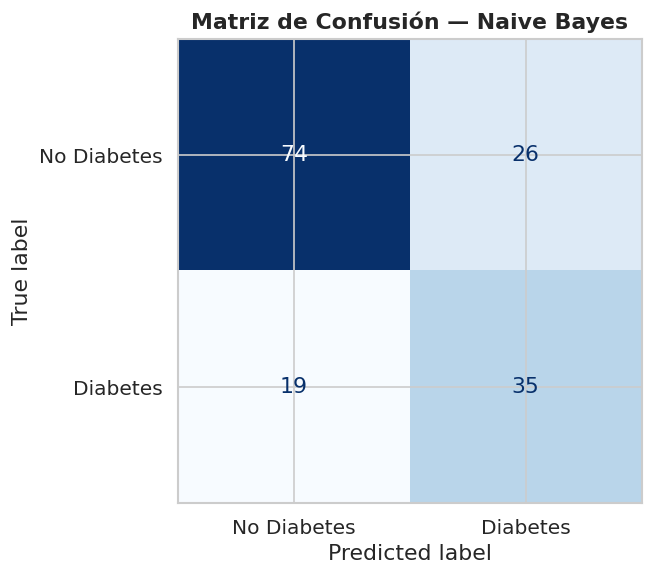


Verdaderos Negativos (TN):  74  — No Diabetes clasificados correctamente
Falsos Positivos     (FP):  26  — No Diabetes clasificados como Diabetes
Falsos Negativos     (FN):  19  — Diabetes clasificados como No Diabetes
Verdaderos Positivos (TP):  35  — Diabetes clasificados correctamente


In [ ]:
# ── Métricas y Matriz de Confusión ────────────────────────────────────────
print('\n MÉTRICAS DE DESEMPEÑO — NAIVE BAYES')
print('=' * 45)
print(classification_report(y_test, y_pred_nb,
      target_names=['No Diabetes', 'Diabetes']))

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb  = recall_score(y_test, y_pred_nb)
f1_nb   = f1_score(y_test, y_pred_nb)
print(f'Accuracy:  {acc_nb:.4f}')
print(f'Precision: {prec_nb:.4f}')
print(f'Recall:    {rec_nb:.4f}')
print(f'F1-Score:  {f1_nb:.4f}')

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', bbox_inches='tight')
plt.show()

# Análisis de la matriz
tn, fp, fn, tp = cm_nb.ravel()
print(f'\nVerdaderos Negativos (TN):  {tn}  — No Diabetes clasificados correctamente')
print(f'Falsos Positivos     (FP):  {fp}  — No Diabetes clasificados como Diabetes')
print(f'Falsos Negativos     (FN):  {fn}  — Diabetes clasificados como No Diabetes')
print(f'Verdaderos Positivos (TP):  {tp}  — Diabetes clasificados correctamente')

In [ ]:
# ── Predicción sobre XDp ─────────────────────────────────────────────────
pred_nb_xdp  = gnb.predict(XDp_raw)[0]
prob_nb_xdp  = gnb.predict_proba(XDp_raw)[0]

print('\n PREDICCIÓN NAIVE BAYES PARA PACIENTE XDp')
print('=' * 45)
print(f'P(No Diabetes): {prob_nb_xdp[0]:.4f}')
print(f'P(Diabetes):    {prob_nb_xdp[1]:.4f}')
etiqueta = 'DIABETES ⚠️' if pred_nb_xdp == 1 else 'NO DIABETES ✅'
print(f'\n➡️  Clasificación: {etiqueta}')


 PREDICCIÓN NAIVE BAYES PARA PACIENTE XDp
P(No Diabetes): 0.8812
P(Diabetes):    0.1188

➡️  Clasificación: NO DIABETES ✅


---
## 5. Modelo 2: Árbol de Decisión (4 niveles)

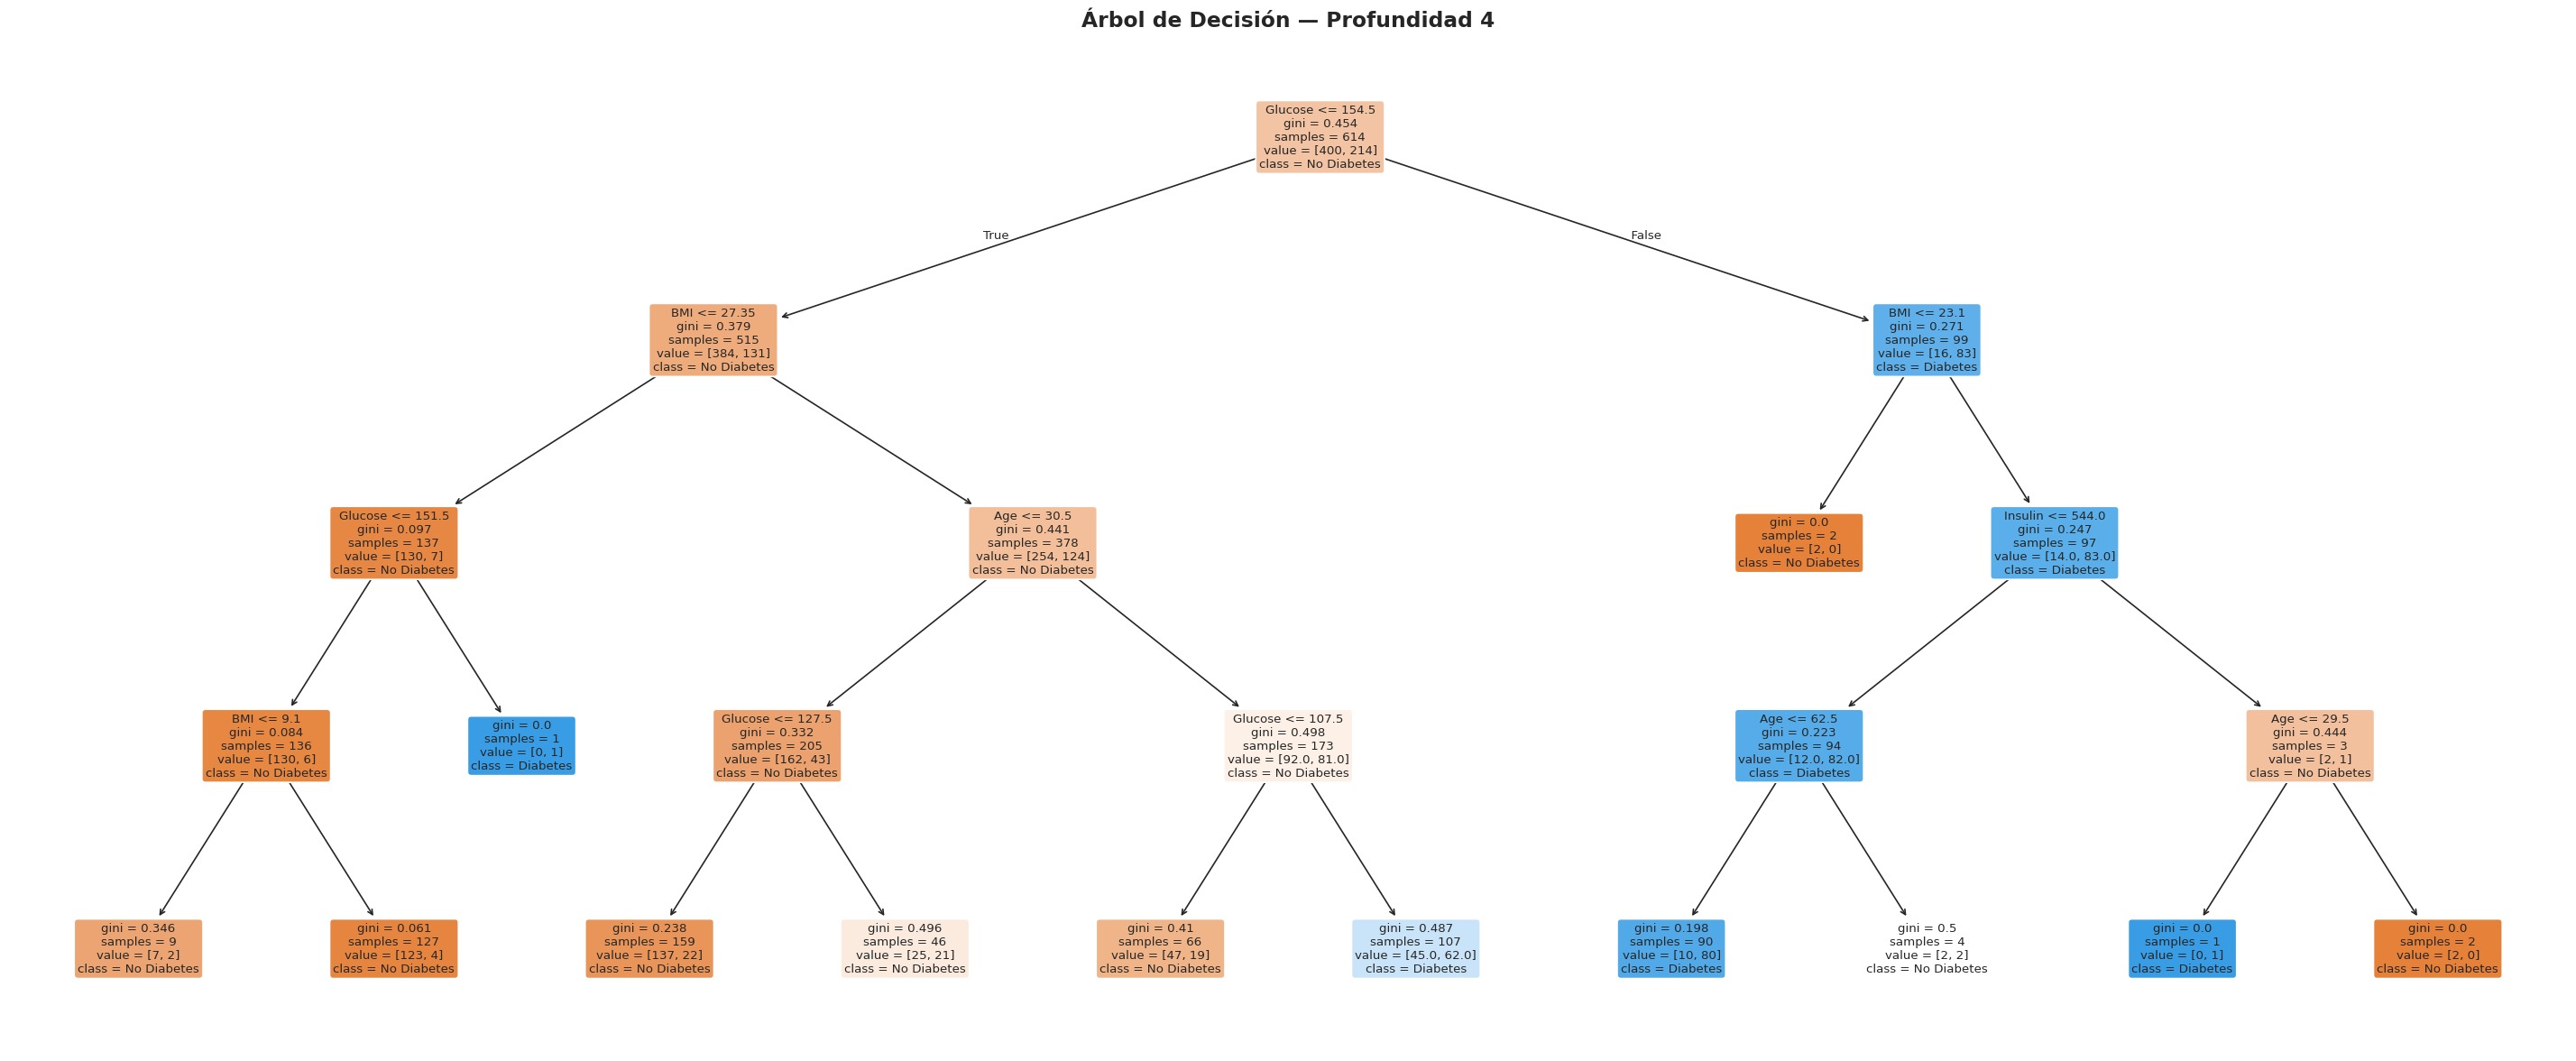

In [ ]:
# ── Entrenamiento con max_depth=4 ─────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Visualización del árbol
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt, feature_names=features, class_names=['No Diabetes', 'Diabetes'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    impurity=True, proportion=False
)
ax.set_title('Árbol de Decisión — Profundidad 4', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('arbol_decision.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── Reglas del árbol ──────────────────────────────────────────────────────
print(' REGLAS DE CLASIFICACIÓN DEL ÁRBOL:')
print('=' * 60)
reglas = export_text(dt, feature_names=features, show_weights=True)
print(reglas)

📋 REGLAS DE CLASIFICACIÓN DEL ÁRBOL (texto):
|--- Glucose <= 154.50
|   |--- BMI <= 27.35
|   |   |--- Glucose <= 151.50
|   |   |   |--- BMI <= 9.10
|   |   |   |   |--- weights: [7.00, 2.00] class: 0
|   |   |   |--- BMI >  9.10
|   |   |   |   |--- weights: [123.00, 4.00] class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- weights: [0.00, 1.00] class: 1
|   |--- BMI >  27.35
|   |   |--- Age <= 30.50
|   |   |   |--- Glucose <= 127.50
|   |   |   |   |--- weights: [137.00, 22.00] class: 0
|   |   |   |--- Glucose >  127.50
|   |   |   |   |--- weights: [25.00, 21.00] class: 0
|   |   |--- Age >  30.50
|   |   |   |--- Glucose <= 107.50
|   |   |   |   |--- weights: [47.00, 19.00] class: 0
|   |   |   |--- Glucose >  107.50
|   |   |   |   |--- weights: [45.00, 62.00] class: 1
|--- Glucose >  154.50
|   |--- BMI <= 23.10
|   |   |--- weights: [2.00, 0.00] class: 0
|   |--- BMI >  23.10
|   |   |--- Insulin <= 544.00
|   |   |   |--- Age <= 62.50
|   |   |   |   |--- weights: [10

In [ ]:
# ── Identificar nodos puros ───────────────────────────────────────────────
tree = dt.tree_
n_nodos = tree.node_count
nodos_puros = []

for i in range(n_nodos):
    # Es hoja (sin hijos)
    if tree.children_left[i] == -1:
        valores = tree.value[i][0]
        total   = valores.sum()
        if valores.min() == 0:  # Puro: solo una clase
            clase = int(np.argmax(valores))
            nodos_puros.append({
                'Nodo': i,
                'Clase': 'Diabetes' if clase == 1 else 'No Diabetes',
                'Muestras': int(total)
            })

df_puros = pd.DataFrame(nodos_puros).sort_values('Muestras', ascending=False)
print(f'\n NODOS PUROS DEL ÁRBOL: {len(df_puros)}')
print('=' * 40)
print(df_puros.to_string(index=False))

nodo_max = df_puros.iloc[0]
print(f'\n Nodo puro con más datos:')
print(f'   Nodo #{int(nodo_max["Nodo"])} → Clase: {nodo_max["Clase"]} | Muestras: {int(nodo_max["Muestras"])}')


 NODOS PUROS DEL ÁRBOL: 4
 Nodo       Clase  Muestras
    6    Diabetes         1
   15 No Diabetes         1
   21    Diabetes         1
   22 No Diabetes         1

 Nodo puro con más datos:
   Nodo #6 → Clase: Diabetes | Muestras: 1


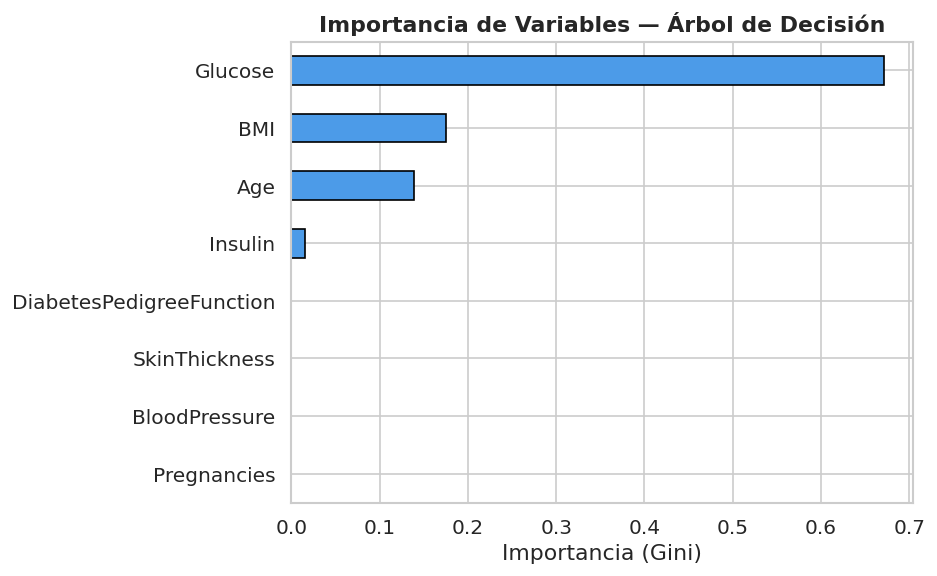

In [ ]:
# ── Importancia de variables ──────────────────────────────────────────────
importancias = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', color='#4C9BE8', edgecolor='black', ax=ax)
ax.set_title('Importancia de Variables — Árbol de Decisión', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.savefig('importancia_vars.png', bbox_inches='tight')
plt.show()

 MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN
              precision    recall  f1-score   support

 No Diabetes       0.82      0.88      0.85       100
    Diabetes       0.74      0.65      0.69        54

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.80      0.80      0.80       154

Accuracy:  0.7987
Precision: 0.7447
Recall:    0.6481
F1-Score:  0.6931


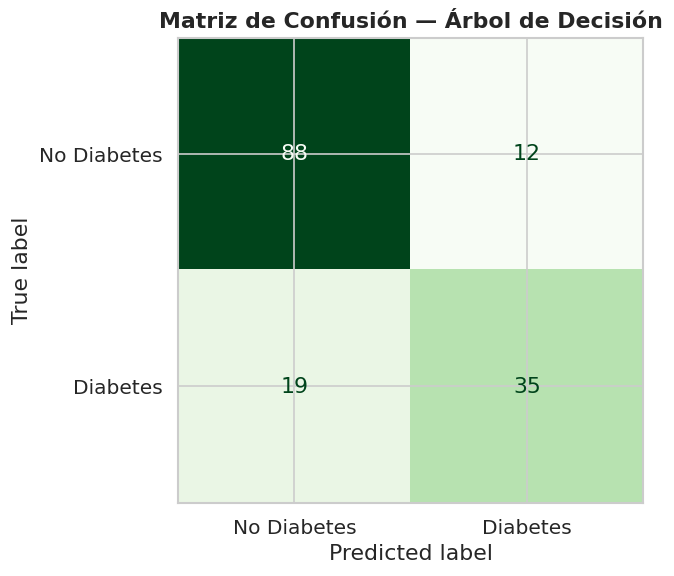

In [ ]:
# ── Métricas ──────────────────────────────────────────────────────────────
print(' MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN')
print('=' * 45)
print(classification_report(y_test, y_pred_dt,
      target_names=['No Diabetes', 'Diabetes']))

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
print(f'Accuracy:  {acc_dt:.4f}')
print(f'Precision: {prec_dt:.4f}')
print(f'Recall:    {rec_dt:.4f}')
print(f'F1-Score:  {f1_dt:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusión — Árbol de Decisión', fontweight='bold')
plt.tight_layout()
plt.savefig('cm_arbol.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Predicción y ruta de decisión para XDp ───────────────────────────────
pred_dt_xdp = dt.predict(XDp_raw)[0]
prob_dt_xdp = dt.predict_proba(XDp_raw)[0]

# Reconstruir la ruta de decisión
nodo_indicator = dt.decision_path(XDp_raw)
nodo_ids = nodo_indicator.indices

print(' PREDICCIÓN ÁRBOL DE DECISIÓN PARA PACIENTE XDp')
print('=' * 55)
print(f'P(No Diabetes): {prob_dt_xdp[0]:.4f}')
print(f'P(Diabetes):    {prob_dt_xdp[1]:.4f}')
etiqueta_dt = 'DIABETES ⚠️' if pred_dt_xdp == 1 else 'NO DIABETES ✅'
print(f'\n  Clasificación: {etiqueta_dt}')

print('\n📍 RUTA DE DECISIÓN (regla de clasificación para XDp):')
for nodo in nodo_ids[:-1]:  # Excluir hoja
    feat_idx = tree.feature[nodo]
    umbral   = tree.threshold[nodo]
    valor    = XDp_raw[0][feat_idx]
    direccion = '≤' if valor <= umbral else '>'
    print(f'  Nodo {nodo}: {features[feat_idx]} = {valor} {direccion} {umbral:.4f}')
print(f'  → Hoja: Clase predicha = {etiqueta_dt}')

 PREDICCIÓN ÁRBOL DE DECISIÓN PARA PACIENTE XDp
P(No Diabetes): 0.8616
P(Diabetes):    0.1384

  Clasificación: NO DIABETES ✅

📍 RUTA DE DECISIÓN (regla de clasificación para XDp):
  Nodo 0: Glucose = 85.0 ≤ 154.5000
  Nodo 1: BMI = 39.6 > 27.3500
  Nodo 7: Age = 27.0 ≤ 30.5000
  Nodo 8: Glucose = 85.0 ≤ 127.5000
  → Hoja: Clase predicha = NO DIABETES ✅


---
## 6. Modelo 3: Clustering K-Means (k=5)

In [ ]:
# ── Entrenamiento K-Means sobre datos escalados ───────────────────────────
X_sc_full = scaler.fit_transform(X)   # Escalar todo el dataset para clustering

km = KMeans(n_clusters=5, random_state=42, n_init=20)
km.fit(X_sc_full)
df['Cluster'] = km.labels_

print('✅ K-Means entrenado con k=5')
print(f'Inercia (WCSS): {km.inertia_:.2f}')

✅ K-Means entrenado con k=5
Inercia (WCSS): 3625.74


In [ ]:
# ── Probabilidad de diabetes por cluster ─────────────────────────────────
resumen_cluster = df.groupby('Cluster').agg(
    Total=('Outcome', 'count'),
    No_Diabetes=('Outcome', lambda x: (x == 0).sum()),
    Diabetes=('Outcome', lambda x: (x == 1).sum())
).reset_index()

resumen_cluster['P(No Diabetes) %'] = (
    resumen_cluster['No_Diabetes'] / resumen_cluster['Total'] * 100
).round(2)
resumen_cluster['P(Diabetes) %'] = (
    resumen_cluster['Diabetes'] / resumen_cluster['Total'] * 100
).round(2)

print(' DISTRIBUCIÓN Y PROBABILIDAD DE DIABETES POR CLUSTER')
print('=' * 65)
print(resumen_cluster.to_string(index=False))

# Cluster con mayor % No Diabetes
top_no_db = resumen_cluster.loc[resumen_cluster['P(No Diabetes) %'].idxmax()]
# Cluster con mayor % Diabetes
top_db = resumen_cluster.loc[resumen_cluster['P(Diabetes) %'].idxmax()]
# Cluster con más pacientes totales
top_total = resumen_cluster.loc[resumen_cluster['Total'].idxmax()]

print(f'\n🔵 Cluster con mayor % No Diabetes: Cluster {int(top_no_db["Cluster"])} ({top_no_db["P(No Diabetes) %"]:.1f}%)')
print(f'🔴 Cluster con mayor % Diabetes:    Cluster {int(top_db["Cluster"])} ({top_db["P(Diabetes) %"]:.1f}%)')
print(f'📦 Cluster con más pacientes:       Cluster {int(top_total["Cluster"])} ({int(top_total["Total"])} pacientes)')

 DISTRIBUCIÓN Y PROBABILIDAD DE DIABETES POR CLUSTER
 Cluster  Total  No_Diabetes  Diabetes  P(No Diabetes) %  P(Diabetes) %
       0    161           78        83           48.4500        51.5500
       1    148           82        66           55.4100        44.5900
       2     36           20        16           55.5600        44.4400
       3    294          263        31           89.4600        10.5400
       4    129           57        72           44.1900        55.8100

🔵 Cluster con mayor % No Diabetes: Cluster 3 (89.5%)
🔴 Cluster con mayor % Diabetes:    Cluster 4 (55.8%)
📦 Cluster con más pacientes:       Cluster 3 (294 pacientes)


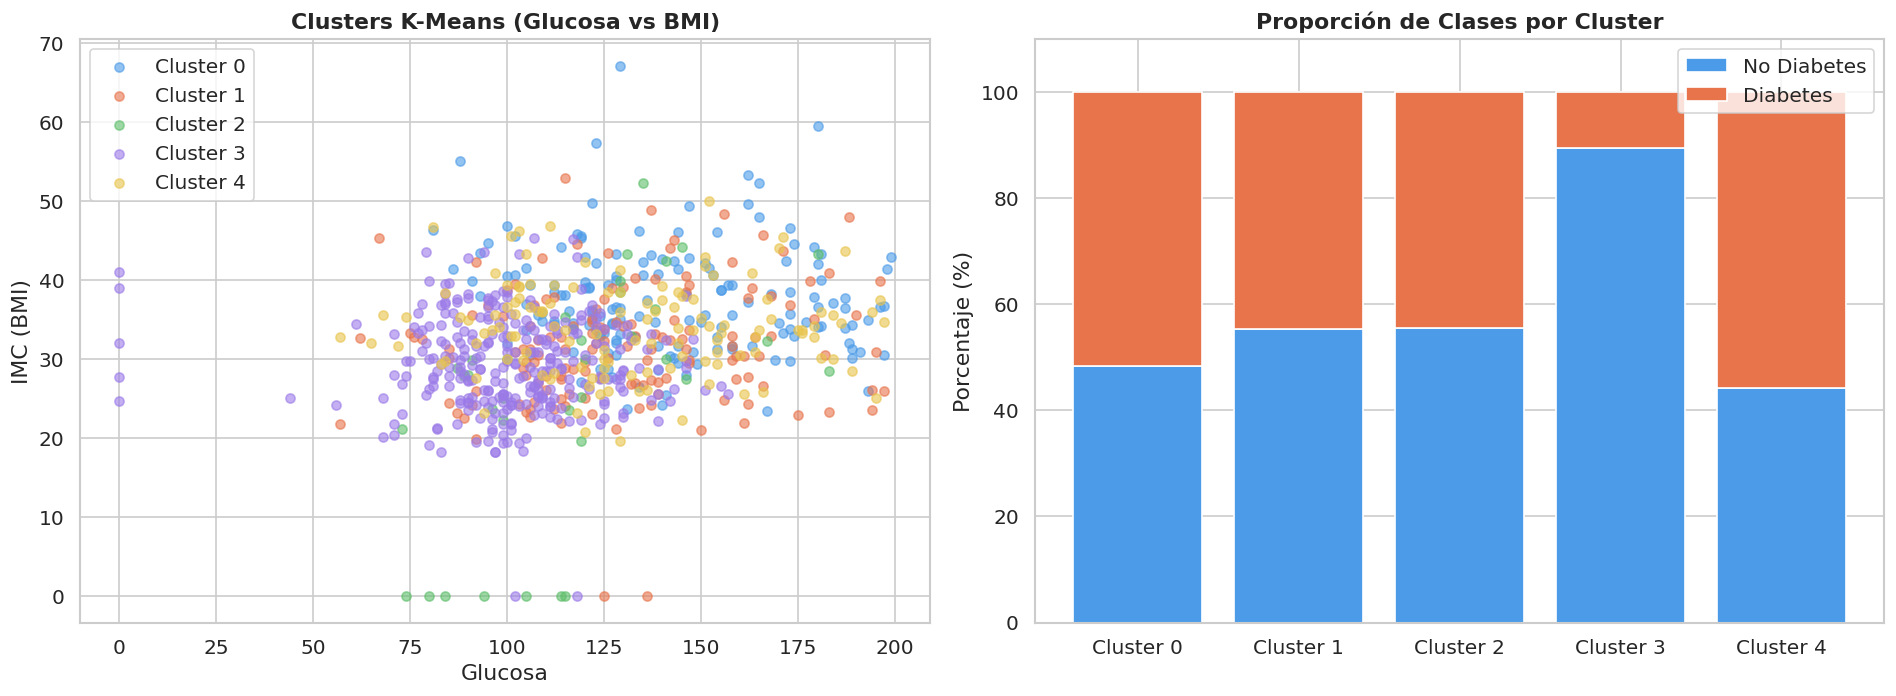

In [ ]:
# ── Visualización clusters ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores_cluster = ['#4C9BE8', '#E8744C', '#5DBE6A', '#9B7AE8', '#E8C44C']

# Scatter Glucose vs BMI coloreado por cluster
for c in range(5):
    mask_c = df['Cluster'] == c
    axes[0].scatter(df.loc[mask_c, 'Glucose'], df.loc[mask_c, 'BMI'],
                   label=f'Cluster {c}', alpha=0.6, s=30,
                   color=colores_cluster[c])
axes[0].set_xlabel('Glucosa')
axes[0].set_ylabel('IMC (BMI)')
axes[0].set_title('Clusters K-Means (Glucosa vs BMI)', fontweight='bold')
axes[0].legend()

# Barras apiladas: % Diabetes por cluster
x = np.arange(5)
axes[1].bar(x, resumen_cluster['P(No Diabetes) %'], label='No Diabetes', color='#4C9BE8')
axes[1].bar(x, resumen_cluster['P(Diabetes) %'],
            bottom=resumen_cluster['P(No Diabetes) %'],
            label='Diabetes', color='#E8744C')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {i}' for i in range(5)])
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Proporción de Clases por Cluster', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Centroides por cluster ────────────────────────────────────────────────
# Invertir escala para interpretación
centroides_orig = scaler.inverse_transform(km.cluster_centers_)
df_centroides = pd.DataFrame(centroides_orig, columns=features)
df_centroides.index.name = 'Cluster'
print('📍 CENTROIDES (valores originales):')
print(df_centroides.round(2).to_string())

📍 CENTROIDES (valores originales):
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  DiabetesPedigreeFunction     Age
Cluster                                                                                                       
0             2.0900 142.0000        72.7700        34.7300 214.9200 37.4300                    0.6000 29.0100
1             5.8600 130.0300        77.5600         0.6600  -0.0000 31.5200                    0.4000 43.6700
2             3.5600 117.0000         0.6700         2.0000   0.6900 25.7600                    0.3900 30.4400
3             2.0000 100.8600        67.2700        19.8500  49.0900 29.1700                    0.4200 25.4000
4             8.0200 130.8100        78.1200        32.3500  94.7800 33.9100                    0.5400 45.2200


In [ ]:
# ── Predicción K-Means para XDp ──────────────────────────────────────────
# Re-escalar con el scaler entrenado sobre TODO el dataset
XDp_sc_full = scaler.transform(XDp_raw)
cluster_xdp = km.predict(XDp_sc_full)[0]

# Distancias del paciente a cada centroide
distancias = np.linalg.norm(km.cluster_centers_ - XDp_sc_full, axis=1)
# Probabilidades inversamente proporcionales a distancias
probs_raw = 1 / (distancias + 1e-9)
probs_norm = probs_raw / probs_raw.sum()

print(' PREDICCIÓN K-MEANS PARA PACIENTE XDp')
print('=' * 55)
print(f'  Cluster asignado: Cluster {cluster_xdp}')
print(f'\n Probabilidad de pertenencia (por distancia) a cada cluster:')
for c, p in enumerate(probs_norm):
    print(f'   Cluster {c}: {p*100:.2f}%')

# % Diabetes en el cluster del paciente
p_diab_cluster = resumen_cluster.loc[
    resumen_cluster['Cluster'] == cluster_xdp, 'P(Diabetes) %'
].values[0]
print(f'\n En el Cluster {cluster_xdp} la probabilidad de Diabetes es: {p_diab_cluster:.1f}%')

print(f'\n Variables del centroide del Cluster {cluster_xdp}:')
print(df_centroides.iloc[cluster_xdp].round(2).to_string())

 PREDICCIÓN K-MEANS PARA PACIENTE XDp
  Cluster asignado: Cluster 3

 Probabilidad de pertenencia (por distancia) a cada cluster:
   Cluster 0: 25.08%
   Cluster 1: 16.41%
   Cluster 2: 12.83%
   Cluster 3: 26.89%
   Cluster 4: 18.80%

 En el Cluster 3 la probabilidad de Diabetes es: 10.5%

 Variables del centroide del Cluster 3:
Pregnancies                  2.0000
Glucose                    100.8600
BloodPressure               67.2700
SkinThickness               19.8500
Insulin                     49.0900
BMI                         29.1700
DiabetesPedigreeFunction     0.4200
Age                         25.4000


---
## 7. Comparación de Modelos

 COMPARACIÓN DE MODELOS SUPERVISADOS
                 Modelo  Accuracy  Precision  Recall  F1-Score
            Naive Bayes    0.7078     0.5738  0.6481    0.6087
Árbol de Decisión (d=4)    0.7987     0.7447  0.6481    0.6931


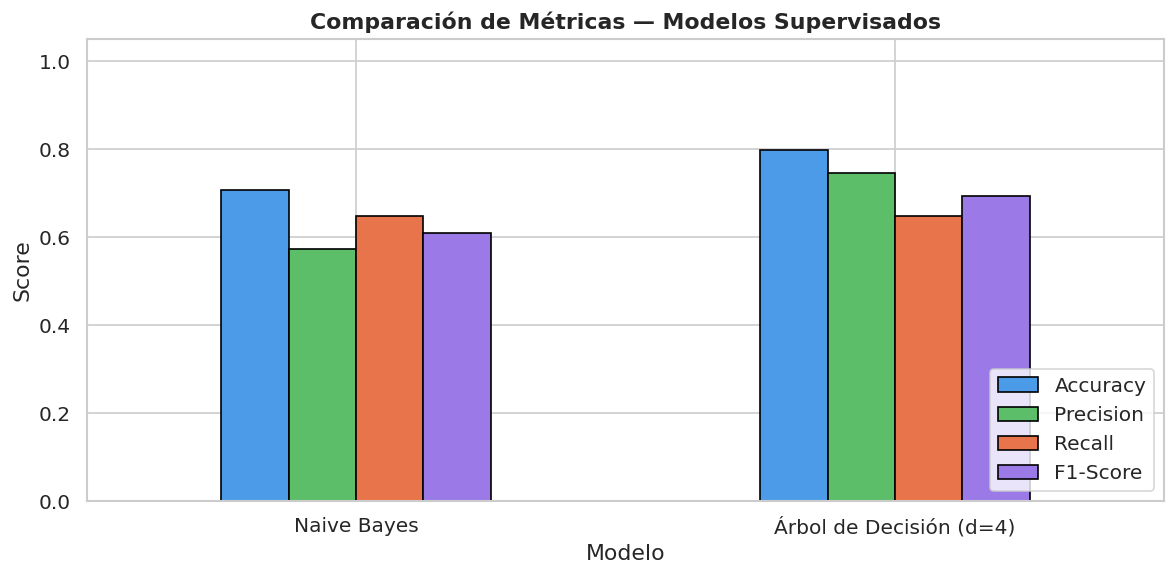

In [ ]:
# ── Tabla comparativa ─────────────────────────────────────────────────────
metricas = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Árbol de Decisión (d=4)'],
    'Accuracy':  [acc_nb,  acc_dt],
    'Precision': [prec_nb, prec_dt],
    'Recall':    [rec_nb,  rec_dt],
    'F1-Score':  [f1_nb,   f1_dt]
})
print(' COMPARACIÓN DE MODELOS SUPERVISADOS')
print('=' * 60)
print(metricas.to_string(index=False))

# Gráfico de barras comparativo
metricas_plot = metricas.set_index('Modelo')
metricas_plot.plot(kind='bar', figsize=(10, 5), rot=0,
                   color=['#4C9BE8', '#5DBE6A', '#E8744C', '#9B7AE8'],
                   edgecolor='black')
plt.title('Comparación de Métricas — Modelos Supervisados', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacion_modelos.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Resumen final de predicciones para XDp ───────────────────────────────
print('\n' + '=' * 60)
print('RESUMEN: PREDICCIONES PARA PACIENTE XDp [2,85,65,29,94,39.6,0.93,27]')
print('=' * 60)
print(f'Naive Bayes:        {"DIABETES ⚠️" if pred_nb_xdp == 1 else "NO DIABETES ✅"}  '
      f'(P_diabetes={prob_nb_xdp[1]:.4f})')
print(f'Árbol de Decisión:  {"DIABETES ⚠️" if pred_dt_xdp == 1 else "NO DIABETES ✅"}  '
      f'(P_diabetes={prob_dt_xdp[1]:.4f})')
print(f'K-Means:            Cluster {cluster_xdp} → P(Diabetes en cluster)={p_diab_cluster:.1f}%')


RESUMEN: PREDICCIONES PARA PACIENTE XDp [2,85,65,29,94,39.6,0.93,27]
Naive Bayes:        NO DIABETES ✅  (P_diabetes=0.1188)
Árbol de Decisión:  NO DIABETES ✅  (P_diabetes=0.1384)
K-Means:            Cluster 3 → P(Diabetes en cluster)=10.5%


---
## 8. Conclusión y Recomendación de Modelo

### Análisis comparativo

| Criterio | Naive Bayes | Árbol de Decisión |
|---|---|---|
| Velocidad de entrenamiento | ✅ Muy rápido | ✅ Rápido |
| Interpretabilidad | 🟡 Media | ✅ Alta (reglas explícitas) |
| Accuracy | Ver celda anterior | Ver celda anterior |
| Manejo de datos nulos | ✅ Robusto | 🟡 Moderado |
| Aplicabilidad en salud | 🟡 Supone independencia | ✅ Reglas claras para médicos |

### Recomendación

**Para este problema de negocio se recomienda el Árbol de Decisión** por las siguientes razones:

1. **Interpretabilidad clínica**: Las reglas `if-then` son directamente comunicables a médicos y personal de salud sin formación técnica.
2. **Criterio de negocio (Recall)**: En diagnóstico médico, minimizar los Falsos Negativos (pacientes con diabetes no detectados) es crítico. El Recall sobre la clase positiva debe priorizarse.
3. **Detección de la variable más importante**: El árbol identifica automáticamente qué variable tiene mayor poder discriminativo (típicamente Glucosa), lo que guía decisiones clínicas.
4. **K-Means como complemento**: El clustering puede usarse para segmentar la población y diseñar intervenciones diferenciadas por grupo de riesgo, no como clasificador final.

